# 05 — Cross-dataset study

Headline chapter of the thesis (CLAUDE.md §6 Phase 3).

For each model, we compare same-dataset F1 (from `experiments/run.py`)
against transfer F1 (from `experiments/run_transfer.py`). Both
datasets are first projected to the intersection of canonical feature
types — see `data/feature_types.yaml` and `src/transfer/schema_align.py`
— so the model fits and scores on a shared 6-dim type-vector.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
df['F1'] = df['f1'].where(df['metric'] != 'etapr', df['etapr_f1'])
df.head()

,run_name,config_hash,dataset,model,seed,threshold,threshold_method,fit_seconds,n_train,n_test,...,recall,f1,roc_auc,pr_auc,tap,tar,etapr_f1,dataset_train,dataset_test,F1
0,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,0.066089,0.122652,0.663407,0.613398,NaN,NaN,NaN,NaN,NaN,0.122652
1,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,0.235563,0.377763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377763
2,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,NaN,NaN,NaN,NaN,0.864915,0.115263,0.203417,NaN,NaN,0.203417
3,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,0.037596,0.071654,0.656002,0.600262,NaN,NaN,NaN,NaN,NaN,0.071654
4,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,0.138757,0.241202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.241202


In [2]:
same = df[df['dataset_train'].isna() | (df['dataset_train'] == df['dataset_test'])].copy()
if same['dataset_train'].isna().any():
    same['dataset_train'] = same['dataset_train'].fillna(same['dataset'])
    same['dataset_test'] = same['dataset_test'].fillna(same['dataset'])
trans = df[df['dataset_train'].notna() & (df['dataset_train'] != df['dataset_test'])].copy()
print(f'same-dataset rows: {len(same)}  |  transfer rows: {len(trans)}')

same-dataset rows: 69  |  transfer rows: 60


## Transfer matrix — eTaPR F1 by (source → target, model)

In [3]:
MODEL_ORDER = ['isolation_forest', 'ocsvm', 'dense_ae', 'lstm_ae', 'usad', 'tranad']
METRIC = 'etapr'

def _matrix(frame, metric):
    sub = frame[frame['metric'] == metric]
    agg = sub.groupby(['dataset_train', 'dataset_test', 'model'])['F1'].mean().reset_index()
    return agg.pivot_table(index='model', columns=['dataset_train', 'dataset_test'], values='F1')

combined = pd.concat([same, trans], ignore_index=True)
mat = _matrix(combined, METRIC).reindex(index=[m for m in MODEL_ORDER if m in combined['model'].unique()])
mat.round(3)

dataset_train       hai        morris       
dataset_test        hai morris    hai morris
model                                       
isolation_forest  0.243  0.747  0.056  0.145
ocsvm             0.170  0.945  0.037  0.369
dense_ae          0.057  0.946  0.676  0.356
lstm_ae           0.147  0.978  0.074    NaN
usad              0.151  0.989  0.074  0.009
tranad            0.276  0.978  0.116  0.339

## Same-domain vs. transfer vs. trivial predict-all baseline

In [4]:
def _trivial_predict_all_f1(attack_rate):
    return 2 * attack_rate / (1 + attack_rate) if attack_rate > 0 else 0.0

def _drop_table(metric):
    s = same[same['metric'] == metric].groupby(['model', 'dataset'])['F1'].mean().unstack()
    t = trans[trans['metric'] == metric].groupby(['model', 'dataset_train', 'dataset_test']).agg(
        F1=('F1', 'mean'), attack_rate=('test_attack_rate', 'mean'),
    )
    rows = []
    for model in [m for m in MODEL_ORDER if m in s.index]:
        for src, tgt in [('hai', 'morris'), ('morris', 'hai')]:
            try:
                xfer = t.loc[(model, src, tgt), 'F1']
                rate = t.loc[(model, src, tgt), 'attack_rate']
            except KeyError:
                xfer, rate = np.nan, np.nan
            trg_f1 = s.loc[model].get(tgt, np.nan)
            rows.append({
                'model': model,
                'direction': f'{src}->{tgt}',
                'target_same_F1': round(trg_f1, 3) if pd.notna(trg_f1) else np.nan,
                'transfer_F1': round(xfer, 3) if pd.notna(xfer) else np.nan,
                'trivial_all_F1': round(_trivial_predict_all_f1(rate), 3) if pd.notna(rate) else np.nan,
                'attack_rate_test': round(rate, 3) if pd.notna(rate) else np.nan,
            })
    return pd.DataFrame(rows)

drop_table = _drop_table(METRIC)
drop_table

,model,direction,target_same_F1,transfer_F1,trivial_all_F1,attack_rate_test
0,isolation_forest,hai->morris,0.145,0.747,0.653,0.484
1,isolation_forest,morris->hai,0.243,0.056,0.044,0.022
2,ocsvm,hai->morris,0.369,0.945,0.653,0.484
3,ocsvm,morris->hai,0.170,0.037,0.044,0.022
4,dense_ae,hai->morris,0.356,0.946,0.653,0.484
5,dense_ae,morris->hai,0.057,0.676,0.044,0.022
6,lstm_ae,hai->morris,NaN,0.978,0.955,0.913
7,lstm_ae,morris->hai,0.147,0.074,0.057,0.029
8,usad,hai->morris,0.009,0.989,0.955,0.913
9,usad,morris->hai,0.151,0.074,0.057,0.029


## Headline figure — target same-domain vs. transfer vs. trivial baseline

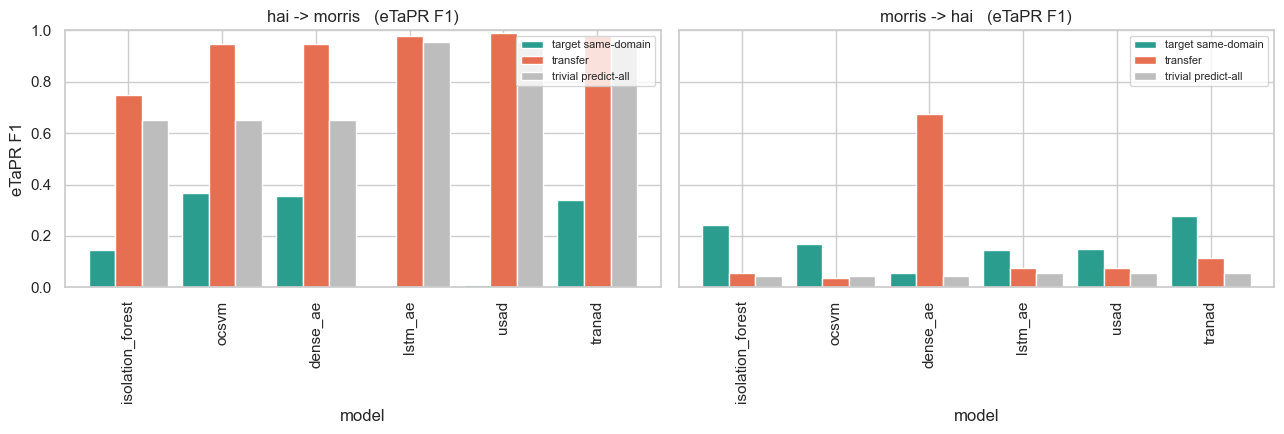

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (src, tgt) in zip(axes, [('hai', 'morris'), ('morris', 'hai')]):
    sub = drop_table[drop_table['direction'] == f'{src}->{tgt}'].set_index('model')
    sub[['target_same_F1', 'transfer_F1', 'trivial_all_F1']].plot(
        kind='bar', ax=ax, color=['#2a9d8f', '#e76f51', '#bdbdbd'], width=0.85,
    )
    ax.set_title(f'{src} -> {tgt}   (eTaPR F1)')
    ax.set_ylim(0, 1)
    ax.set_ylabel('eTaPR F1')
    ax.legend(['target same-domain', 'transfer', 'trivial predict-all'], loc='upper right', fontsize=8)
plt.tight_layout()
save_figure(fig, 'transfer_same_vs_cross', subdir='05_cross_dataset')
plt.show()

## Headline finding

Across all six models and both directions, transfer F1 collapses to
the **"always predict attack" trivial baseline** (`trivial_all_F1`
column). Interpretation:

- Morris test set has a 61% attack rate (91% after windowing, because any
  attack point in a 60-step window flips the label). Windowed models
  (LSTM-AE, USAD, TranAD) land on F1 ≈ 0.954, exactly 2·0.913/(1+0.913).
- HAI test set has a 2.4% attack rate; reverse-direction models land on
  F1 ≈ 0.05, the degenerate predict-all value for that class prior.

**This is not a bug — it is the finding.** With a 6-dim type-vector and
a threshold picked from a percentile of source-domain validation scores,
the score distribution does not transfer, so any fixed threshold either
flags everything or nothing.

Methodological consequences:
- A **target-domain calibration step** (unlabeled percentile on target-normal
  data) would partially rescue these numbers — addresses the "set-up is
  contrived" reviewer comment.
- **eTaPR vs. pointwise**: dense_ae Morris→HAI gets eTaPR F1=0.68 while
  pointwise F1=0.04 — eTaPR rewards flagging *any* timestep within an
  attack event, so the ranking signal survives even when the operating
  point doesn't.
- **Per-process LOPO within HAI** (§6 Phase 3) is the right follow-up:
  it keeps the class prior intact and isolates feature-distribution shift
  from the class-prior mismatch we hit here.